In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import holidays

In [ ]:
#Taking weather data

pd_1 = pd.read_csv("daily_top11-51_cities_2020-2026_2026-04-04_extracted.csv")
pd_2 = pd.read_csv("daily_top0-10_cities_2020-2026_2026-04-05_extracted.csv")
df_provinces_weather = pd.concat([pd_2, pd_1], ignore_index=True)
df_provinces_weather["prov"] = df_provinces_weather["city"]
display(df_provinces_weather)

,date,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,sunrise,sunset,daylight_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,surface_pressure_mean,et0_fao_evapotranspiration_sum,city,prov
0,2020-01-01 00:00:00+00:00,2.0,3.147917,11.250000,-2.300,0.386449,9.178235,11.520000,9.33,1577864282,1577897875,33592.332,0.000000,0.000000,0.0,0.0,952.29004,1.082871,Madrid,Madrid
1,2020-01-02 00:00:00+00:00,3.0,2.483333,9.300000,-2.500,-0.423794,8.534353,12.959999,9.23,1577950689,1577984326,33636.273,0.000000,0.000000,0.0,0.0,951.68830,1.020405,Madrid,Madrid
2,2020-01-03 00:00:00+00:00,3.0,1.568750,6.600000,-1.500,-1.070321,8.209263,12.959999,6.72,1578037094,1578070778,33683.930,0.000000,0.000000,0.0,0.0,953.31730,0.700336,Madrid,Madrid
3,2020-01-04 00:00:00+00:00,1.0,3.754167,10.250000,-1.250,0.239713,17.057314,38.160000,8.87,1578123497,1578157232,33735.215,0.000000,0.000000,0.0,0.0,954.55540,1.079652,Madrid,Madrid
4,2020-01-05 00:00:00+00:00,0.0,3.179167,11.450000,-2.350,0.025346,9.931042,19.440000,9.41,1578209897,1578243688,33790.030,0.000000,0.000000,0.0,0.0,950.72284,1.111593,Madrid,Madrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118295,2026-03-20 00:00:00+00:00,61.0,14.105999,15.481000,13.531,10.870917,38.312946,74.880000,6.01,1773987913,1774031597,43681.805,14.700002,14.700002,0.0,21.0,1004.32180,1.094613,Ceuta,Ceuta
118296,2026-03-21 00:00:00+00:00,51.0,14.510169,15.781000,13.831,11.446494,27.504095,56.519997,9.81,1774074228,1774118048,43818.050,1.200000,1.200000,0.0,10.0,1004.84720,1.689053,Ceuta,Ceuta
118297,2026-03-22 00:00:00+00:00,51.0,14.643500,16.881000,13.331,12.026841,24.948025,50.399998,16.73,1774160543,1774204499,43953.625,0.100000,0.100000,0.0,1.0,1005.63310,2.503936,Ceuta,Ceuta
118298,2026-03-23 00:00:00+00:00,1.0,14.889335,17.731000,13.031,13.187428,25.600530,49.680000,21.12,1774246859,1774290949,44088.610,0.000000,0.000000,0.0,0.0,1008.26105,2.969439,Ceuta,Ceuta


In [ ]:
provinces_data = pd.read_csv("Provinces_data.csv")
provinces_data.head()

,Capital,Comunidad autónoma,Nombre oficial,Poblacion,Superficie,%Poblacion,%Superficie2,lat,lon,prov,code
0,Madrid,Comunidad de Madrid,Madrid,7113886,8028,0.144802,0.015866,40.495,-3.7170,Madrid,28
1,Barcelona,Cataluña,Barcelona,5959941,7728,0.121314,0.015273,41.730,1.9837,Barcelona,8
2,Valencia,Comunitat Valenciana,Valencia/València,2763996,10807,0.056261,0.021358,39.370,-0.8000,Valencia,46
3,Alicante,Comunitat Valenciana,Alicante/Alacant,2033566,5817,0.041393,0.011496,38.478,-0.5680,Alicante,3
4,Sevilla,Andalucía,Sevilla,1977664,14036,0.040255,0.027740,37.435,-5.6820,Sevilla,41


In [ ]:
df_merged = pd.merge(df_provinces_weather, provinces_data, on="prov", how="left")
df_merged

,date,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,sunrise,...,Capital,Comunidad autónoma,Nombre oficial,Poblacion,Superficie,%Poblacion,%Superficie2,lat,lon,code
0,2020-01-01 00:00:00+00:00,2.0,3.147917,11.250000,-2.300,0.386449,9.178235,11.520000,9.33,1577864282,...,Madrid,Comunidad de Madrid,Madrid,7113886,8028,0.144802,0.015866,40.495,-3.717,28
1,2020-01-02 00:00:00+00:00,3.0,2.483333,9.300000,-2.500,-0.423794,8.534353,12.959999,9.23,1577950689,...,Madrid,Comunidad de Madrid,Madrid,7113886,8028,0.144802,0.015866,40.495,-3.717,28
2,2020-01-03 00:00:00+00:00,3.0,1.568750,6.600000,-1.500,-1.070321,8.209263,12.959999,6.72,1578037094,...,Madrid,Comunidad de Madrid,Madrid,7113886,8028,0.144802,0.015866,40.495,-3.717,28
3,2020-01-04 00:00:00+00:00,1.0,3.754167,10.250000,-1.250,0.239713,17.057314,38.160000,8.87,1578123497,...,Madrid,Comunidad de Madrid,Madrid,7113886,8028,0.144802,0.015866,40.495,-3.717,28
4,2020-01-05 00:00:00+00:00,0.0,3.179167,11.450000,-2.350,0.025346,9.931042,19.440000,9.41,1578209897,...,Madrid,Comunidad de Madrid,Madrid,7113886,8028,0.144802,0.015866,40.495,-3.717,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118295,2026-03-20 00:00:00+00:00,61.0,14.105999,15.481000,13.531,10.870917,38.312946,74.880000,6.01,1773987913,...,-,Ciudad Autónoma de Ceuta,Ceuta,83567,19,0.001701,0.000038,35.893,-5.342,51
118296,2026-03-21 00:00:00+00:00,51.0,14.510169,15.781000,13.831,11.446494,27.504095,56.519997,9.81,1774074228,...,-,Ciudad Autónoma de Ceuta,Ceuta,83567,19,0.001701,0.000038,35.893,-5.342,51
118297,2026-03-22 00:00:00+00:00,51.0,14.643500,16.881000,13.331,12.026841,24.948025,50.399998,16.73,1774160543,...,-,Ciudad Autónoma de Ceuta,Ceuta,83567,19,0.001701,0.000038,35.893,-5.342,51
118298,2026-03-23 00:00:00+00:00,1.0,14.889335,17.731000,13.031,13.187428,25.600530,49.680000,21.12,1774246859,...,-,Ciudad Autónoma de Ceuta,Ceuta,83567,19,0.001701,0.000038,35.893,-5.342,51


In [ ]:
# 1. Ensure the date column is in datetime format
df_merged['date'] = pd.to_datetime(df_merged['date'], utc=True).dt.tz_localize(None)

# 2. Define the columns for each weighting method
cols_pop = ['weather_code', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_mean']
cols_surf = ['wind_speed_10m_max', 'wind_gusts_10m_max', 'shortwave_radiation_sum', 'precipitation_sum', 
             'rain_sum', 'snowfall_sum', 'precipitation_hours', 'surface_pressure_mean', 'et0_fao_evapotranspiration_sum']

# 3. Calculate the weighted components
# We multiply the variable by the weight. Later, we divide by the sum of the weights 
# to ensure it averages correctly even if you didn't include all 52 provinces.
for col in cols_pop:
    df_merged[f'{col}_w'] = df_merged[col] * df_merged['%Poblacion']
for col in cols_surf:
    df_merged[f'{col}_w'] = df_merged[col] * df_merged['%Superficie2']

# Define how to aggregate the columns (summing the weighted parts)
agg_funcs = {f'{col}_w': 'sum' for col in cols_pop + cols_surf}
agg_funcs['%Poblacion'] = 'sum'
agg_funcs['%Superficie2'] = 'sum'

# Group by date to get daily national data
df_final = df_merged.groupby('date').agg(agg_funcs)

# Divide by the total weight to get the final weighted average
for col in cols_pop:
    df_final[col] = df_final[f'{col}_w'] / df_final['%Poblacion']
for col in cols_surf:
    df_final[col] = df_final[f'{col}_w'] / df_final['%Superficie2']

# Clean up the intermediate calculation columns
cols_to_drop = [f'{col}_w' for col in cols_pop + cols_surf] + ['%Poblacion', '%Superficie2']
df_final = df_final.drop(columns=cols_to_drop)

# 4. Extract Madrid's sunrise and sunset
# Filter for Madrid, set date as index, and assign to final dataframe
df_madrid = df_merged[df_merged['prov'].str.contains('Madrid', case=False, na=False)].set_index('date')
df_final['sunrise'] = df_madrid['sunrise']
df_final['sunset'] = df_madrid['sunset']

# 5. Calculate Extreme Temperatures (Peninsular) and Windspeed
# Exclude non-peninsular territories
non_peninsular = ['Canarias', 'Las Palmas', 'Santa Cruz de Tenerife', 'Baleares', 'Illes Balears', 'Ceuta', 'Melilla']
df_peninsular = df_merged[~df_merged['Comunidad autónoma'].isin(non_peninsular) & ~df_merged['prov'].isin(non_peninsular)]

# Get the 3rd biggest/smallest values per day
# .nlargest(3).min() takes the top 3 values and grabs the lowest of those 3 (which is the 3rd biggest overall)
df_final['peninsular_max_temperature'] = df_peninsular.groupby('date')['temperature_2m_max'].apply(lambda x: x.nlargest(3).min())
df_final['peninsular_min_temperature'] = df_peninsular.groupby('date')['temperature_2m_min'].apply(lambda x: x.nsmallest(3).max())
df_final['max_windspeed'] = df_merged.groupby('date')['wind_speed_10m_max'].apply(lambda x: x.nlargest(3).min())

# 6. Add Derived Weather Features
df_final['daily_temperature_range'] = df_final['temperature_2m_max'] - df_final['temperature_2m_min']
# Shift(1) ensures the current day is NOT included in the 3-day rolling average
df_final['rolling_avg_temp'] = df_final['temperature_2m_mean'].shift(1).rolling(window=3).mean().fillna(df_final['temperature_2m_mean'])
df_final['delta_temp_with_previous'] = df_final['temperature_2m_mean'] - df_final['rolling_avg_temp']
df_final['std_avg_temperature'] = df_merged.groupby('date')['temperature_2m_mean'].std()

# 7. Add Calendar and Holiday Features
df_final = df_final.reset_index() # Bring date back as a standard column

df_final['Day_of_the_week'] = df_final['date'].dt.dayofweek + 1 # 1=Monday, 7=Sunday
df_final['Is_weekend'] = df_final['Day_of_the_week'].apply(lambda x: 1 if x >= 6 else 0)
df_final['Month'] = df_final['date'].dt.month
df_final['Year'] = df_final['date'].dt.year - 2020 # 0 for 2020, 6 for 2026

# Map months to seasons (1=Winter, 2=Spring, 3=Summer, 4=Autumn)
season_map = {12: 4, 1: 1, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2, 7: 3, 8: 3, 9: 3, 10: 4, 11: 4}
df_final['Season'] = df_final['Month'].map(season_map)

# Add Spanish National Holidays
es_holidays = holidays.Spain(years=range(2020, 2027))
df_final['Is_national_holiday'] = df_final['date'].dt.date.apply(lambda x: 1 if x in es_holidays else 0)

# Display the final prepared dataset
display(df_final)

,date,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,precipitation_sum,...,daily_temperature_range,rolling_avg_temp,delta_temp_with_previous,std_avg_temperature,Day_of_the_week,Is_weekend,Month,Year,Season,Is_national_holiday
0,2020-01-01,3.373905,6.535541,12.122852,2.473909,4.048853,9.113214,17.929255,8.995457,0.002096,...,9.648943,6.535541,0.000000,4.271009,3,0,1,0,1,1
1,2020-01-02,3.544995,6.054612,11.025364,2.240265,3.353892,9.889774,20.888576,8.473975,0.002665,...,8.785099,6.054612,0.000000,4.290235,4,0,1,0,1,0
2,2020-01-03,10.193813,6.174448,10.575465,2.901268,3.515991,11.881113,23.915295,6.650877,0.297608,...,7.674197,6.174448,0.000000,4.273692,5,0,1,0,1,0
3,2020-01-04,7.694727,6.525313,11.145725,3.126518,3.779529,13.375087,28.558504,7.511187,0.080288,...,8.019207,6.254867,0.270446,3.747642,6,1,1,0,1,0
4,2020-01-05,3.050183,6.535853,12.627845,2.317812,3.727290,11.201827,23.020813,9.135439,0.010137,...,10.310033,6.251458,0.284396,3.866587,7,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2270,2026-03-20,37.033402,10.662229,14.810132,7.027795,8.039084,17.367933,36.608237,13.960758,2.193857,...,7.782338,11.991825,-1.329596,2.860329,5,0,3,6,1,0
2271,2026-03-21,32.285909,10.213298,14.596530,6.447080,8.110780,13.083689,28.536579,13.911325,1.337886,...,8.149451,11.458459,-1.245161,2.848667,6,1,3,6,1,0
2272,2026-03-22,23.569266,10.588294,16.492602,5.173598,8.534571,14.831351,32.016640,18.881510,0.774670,...,11.319004,10.833741,-0.245447,2.673024,7,1,3,6,1,0
2273,2026-03-23,18.726266,10.668709,16.338864,5.612123,8.313272,16.385160,34.963588,19.138130,0.208758,...,10.726742,10.487940,0.180769,3.161416,1,0,3,6,1,0


In [ ]:
df_final.describe()

,date,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,precipitation_sum,...,daily_temperature_range,rolling_avg_temp,delta_temp_with_previous,std_avg_temperature,Day_of_the_week,Is_weekend,Month,Year,Season,Is_national_holiday
count,2275,2275.000000,2275.000000,2275.000000,2275.000000,2275.000000,2275.000000,2275.000000,2275.000000,2275.000000,...,2275.000000,2275.000000,2275.000000,2275.000000,2275.00000,2275.000000,2275.000000,2275.000000,2275.000000,2275.000000
mean,2023-02-11 00:00:00,24.155504,15.323524,20.560998,10.752193,13.719554,17.705070,37.925481,16.447849,1.841230,...,9.808805,15.319446,0.004078,3.452164,4.00000,0.285714,6.353846,2.627253,2.453187,0.023736
min,2020-01-01 00:00:00,0.259705,1.982134,4.749824,-1.968996,-2.012239,9.083519,17.929255,3.002020,0.000000,...,3.909761,2.492028,-6.947188,1.472919,1.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2021-07-22 12:00:00,10.351841,10.140471,14.623068,6.190313,7.606702,14.846726,32.064656,9.619839,0.130883,...,7.937844,10.106799,-0.982175,2.925500,2.00000,0.000000,3.000000,1.000000,1.000000,0.000000
50%,2023-02-11 00:00:00,20.267523,14.320583,19.535295,10.045373,12.563318,17.234969,37.199190,15.958700,0.609901,...,9.845476,14.353023,0.093577,3.431335,4.00000,0.000000,6.000000,3.000000,2.000000,0.000000
75%,2024-09-01 12:00:00,36.155899,20.593143,26.441801,15.550765,20.177179,19.630825,42.250563,23.521923,2.343554,...,11.690034,20.618154,1.094910,3.927610,6.00000,1.000000,9.000000,4.000000,3.000000,0.000000
max,2026-03-24 00:00:00,64.778212,29.459220,37.113322,22.791370,29.375628,38.607394,88.260360,29.886754,27.549194,...,15.211708,28.963090,4.756502,5.986974,7.00000,1.000000,12.000000,6.000000,4.000000,1.000000
std,NaN,16.562118,6.338948,7.057721,5.599267,7.525150,4.328921,9.139204,7.445842,2.783897,...,2.322803,6.288691,1.621596,0.704238,2.00044,0.451853,3.498093,1.800995,1.132739,0.152260


In [ ]:
df_final.to_csv("final_prepared_dataset.csv", index=False)

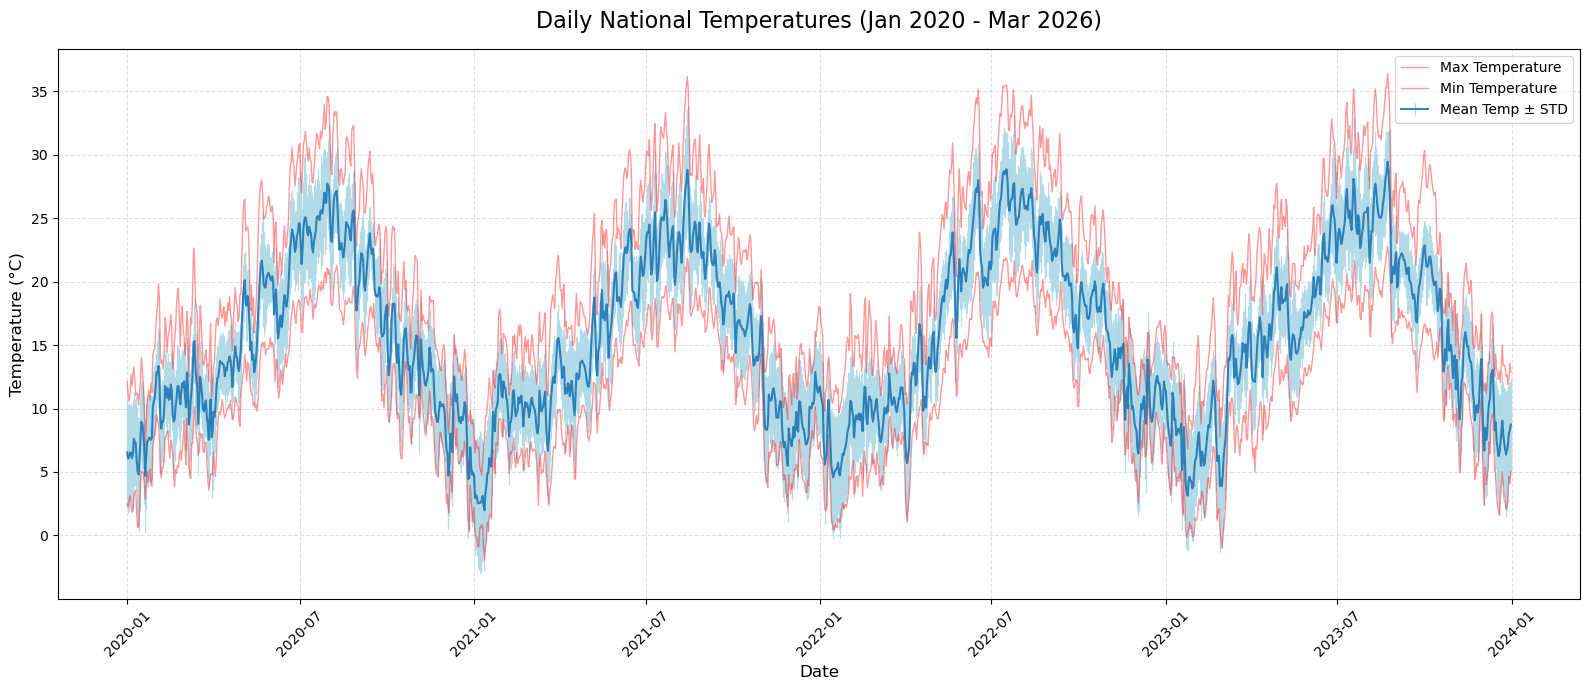

In [ ]:
plt.figure(figsize=(16, 7))

df_graph = df_final[df_final['Year'] < 4] # Exclude 2026 data for cleaner visualization

# 1. Plot the mean temperature with error bars
plt.errorbar(
    x=df_graph['date'], 
    y=df_graph['temperature_2m_mean'], 
    yerr=df_graph['std_avg_temperature'], 
    fmt='-',                 # Connect points with a solid line
    color='#1f77b4',         # Main line color (Blue)
    ecolor='lightblue',      # Error bar color (lighter to not overwhelm the chart)
    elinewidth=0.9,          # Very thin error bars since there are 2,200+ days
    alpha=0.9,
    label='Mean Temp ± STD'
)

# 2. Plot the Max and Min temperatures as grey lines
plt.plot(df_graph['date'], df_graph['temperature_2m_max'], color='red', alpha=0.4, linewidth=1, label='Max Temperature')
plt.plot(df_graph['date'], df_graph['temperature_2m_min'], color='red', alpha=0.4, linewidth=1, label='Min Temperature')

# 3. Add formatting, titles, and legends
plt.title('Daily National Temperatures (Jan 2020 - Mar 2024)', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()